<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [ ]:
!pip install pandas
!pip install matplotlib

Import pandas module


In [2]:
import pandas as pd


Import matplotlib


In [3]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [4]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [16]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [5]:
## Write your code here
duprows = df[df.duplicated(keep=False)]
print("Total duplicate rows (keeping first):", len(duprows))
duprows.head()

Total duplicate rows (keeping first): 40


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [6]:
#investigate duplicated rows except ResponseId column
cols = [c for c in df.columns if c != "ResponseId"]
dup_mask = df.duplicated(subset=cols, keep=False)
dup_df = df[dup_mask]
print("Number of duplicated rows with keep=False = ",dup_df.shape[0])

Number of duplicated rows with keep=False =  661


In [7]:
num_gr = dup_df.groupby(cols, dropna=False)["ResponseId"].agg(
    group_size='count',
    response_ids=lambda x: list(x)
    # group_size=('ResponseId','count'),
    # response_ids=('ResponseId',list)
)
clusters = num_gr['response_ids'].values
print("Number of duplicated clusters = ",len(clusters))

Number of duplicated clusters =  154


### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [8]:
## Write your code here
dup_summary = (
    df.groupby(['MainBranch', 'Employment', 'RemoteWork'])
      .size()
      .reset_index(name='count')
)
dup_summary = dup_summary[dup_summary['count'] > 1]
dup_summary = dup_summary.sort_values(by='count', ascending=False).reset_index()
dup_summary[['MainBranch', 'Employment', 'RemoteWork', 'count']]

,MainBranch,Employment,RemoteWork,count
0,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",15288
1,I am a developer by profession,"Employed, full-time",Remote,12196
2,I am a developer by profession,"Employed, full-time",In-person,7118
3,I am a developer by profession,"Independent contractor, freelancer, or self-em...",Remote,2815
4,I am a developer by profession,"Employed, full-time;Independent contractor, fr...",Remote,1754
...,...,...,...,...
314,I am a developer by profession,"Employed, full-time;Student, full-time;Student...","Hybrid (some remote, some in-person)",2
315,I am a developer by profession,"Employed, full-time;Student, full-time;Not emp...",In-person,2
316,"I used to be a developer by profession, but no...","Student, full-time;Employed, part-time","Hybrid (some remote, some in-person)",2
317,"I used to be a developer by profession, but no...","Student, full-time;Employed, part-time",Remote,2


### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


In [9]:
## Write your code here
import plotly.express as px
top_summary = dup_summary[['MainBranch', 'Employment', 'RemoteWork', 'count']].head(15)
top_summary['GroupLabel'] = (
    top_summary['MainBranch'] + ' | ' +
    top_summary['Employment'] + ' | ' +
    top_summary['RemoteWork'].astype(str)
)
fig = px.bar(
    top_summary,
    x='count',
    y='GroupLabel',
    title='Top 15 duplicated group counts'
)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

In [10]:

dup_summary['Group_ID'] = ['G' + str(i+1) for i in range(len(dup_summary))]
fig = px.bar(
    dup_summary.head(15),
    x='Group_ID', 
    y='count',
    hover_data=['MainBranch', 'Employment', 'RemoteWork'],
    title='Top 15 Duplicated Group Counts'
)
fig.show()

In [11]:
fig = px.treemap(
    dup_summary,
    path=['MainBranch', 'Employment', 'RemoteWork'],
    values='count',
    title='Top 15 Duplicated Group Counts(Treemap)'
)
fig.show()

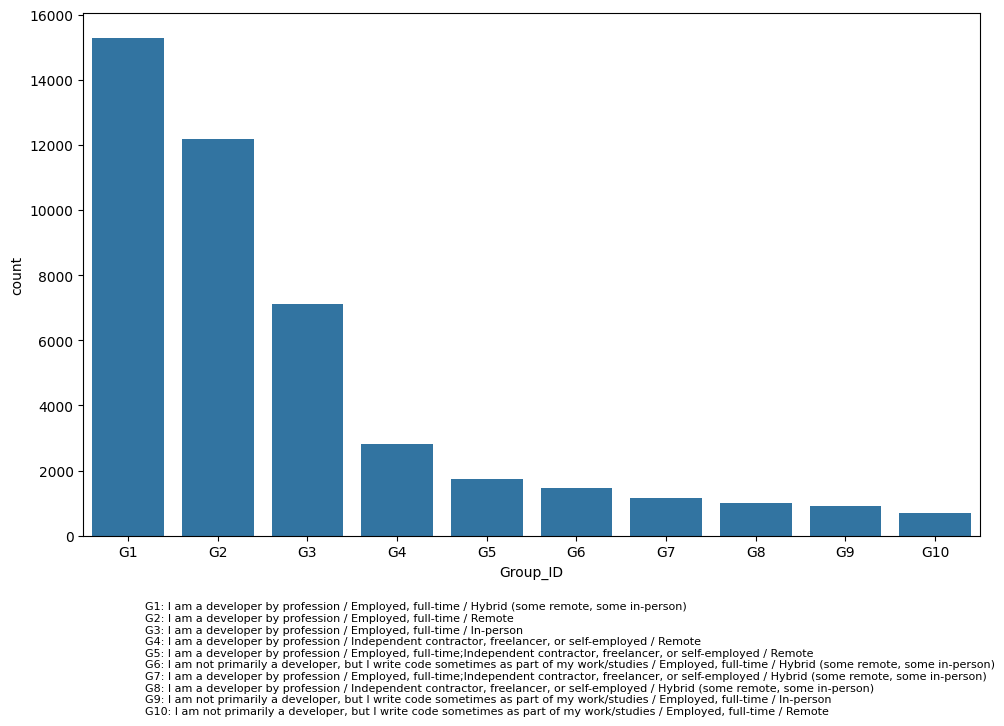

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=dup_summary.head(10), x='Group_ID', y='count')
legend_text = "\n".join([f"{row.Group_ID}: {row.MainBranch} / {row.Employment} / {row.RemoteWork}" 
                         for _, row in dup_summary.head(10).iterrows()])
plt.figtext(0.15, -0.2, legend_text, fontsize=8, ha="left")
plt.tight_layout()
plt.show()

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


In [ ]:
## Write your analysis here
#Analyse the dataset to determine which column(s) can define record uniqueness
print("Total rows = ",df.shape[0])
df = df.drop_duplicates(keep='first')

for col in df.columns:
    ucnt = df[col].nunique()
    if ucnt==df.shape[0]:
        print(col," ",ucnt)
## Conclusion
## The 'ResponseId' is the only one column which can define record uniqueness

Total rows =  65457
ResponseId   65437


In [ ]:
##Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
cols = [c for c in df.columns if c != "ResponseId"]
dup_mask = df.duplicated(subset=cols, keep=False)
dup_df = df[dup_mask]
print("Number of duplicated rows with 'keep=False' : ",dup_df.shape[0])
num_gr = dup_df.groupby(cols, dropna=False)["ResponseId"].agg(
    group_size='count',
    response_ids=lambda x: list(x)
)
clusters = num_gr['response_ids'].values
print("Number of duplicated clusters : ",len(clusters))
dup_df_1 = df[df.duplicated(subset=cols, keep='first')]
print("Number of duplicated rows with 'keep='first' : ",dup_df_1.shape[0])

## Conclusion
## If all columns except 'ResponseId' are same, then the two rows are same.
## Total 487 rows can be dropped as duplicated rows.
## But Investigating the 621 duplicated rows, the filled fields are only 4-7 entries and other fields are null ones. 

Number of duplicated rows with 'keep=False' :  621
Number of duplicated clusters :  134
Number of duplicated rows with 'keep='first' :  487


In [ ]:
num_gr_ri = num_gr.reset_index()
num_gr_ri.columns

#dup49ids = [44050, 47681, 47712, 47892, 48285, 52504, 54575, 55065, 55093, 55100, 55575, 55708, 56238, 56323, 56346, 56870, 57716, 58199, 58200, 58911, 60459, 61428, 61745, 61838, 61982, 62442, 62475, 62563, 62695, 62827, 62948, 63102, 63178, 63203, 63226, 63270, 63461, 63602, 63717, 63873, 63946, 63951, 64070, 64709, 64781, 64825, 65212, 65382, 65392]
#df.iloc[dup49ids]

Index(['MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       'TechDoc',
       ...
       'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10',
       'JobSatPoints_11', 'SurveyLength', 'SurveyEase', 'ConvertedCompYearly',
       'JobSat', 'group_size', 'response_ids'],
      dtype='object', length=115)

In [97]:
#for col in num_gr_ri.columns:
#    print(num_gr_ri[col].notnull().sum())
#for i in range(num_gr_ri.shape[0]):
#    print(num_gr_ri.iloc[i].notnull().sum())
num_gr_ri.notnull().sum(axis=1).value_counts().sort_index()
# num_gr_ri.columns

6     24
7     42
8     64
9      1
10     2
11     1
Name: count, dtype: int64

In [65]:
import numpy as np
lengths = [len(x) for x in clusters]
lengths.sort()
print(len(lengths))
print(lengths)
cnt=2
instcnt=0
acc=[]
for i in range(len(lengths)):
    if lengths[i]==cnt:
        instcnt += 1
    else:
        acc.append((cnt,instcnt))
        instcnt=1;
        cnt = lengths[i]
acc.append((cnt,instcnt))
duptot=0
for i in range(len(acc)):
    duptot += acc[i][0]*acc[i][1]
print(duptot)
acc        

134
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 9, 9, 10, 11, 16, 16, 17, 17, 18, 35, 36, 49]
621


[(2, 60),
 (3, 34),
 (4, 12),
 (5, 4),
 (6, 2),
 (7, 4),
 (8, 6),
 (9, 2),
 (10, 1),
 (11, 1),
 (16, 2),
 (17, 2),
 (18, 1),
 (35, 1),
 (36, 1),
 (49, 1)]

## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
